In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# 1. 데이터 로드
df = pd.read_csv('./data/bike_train.csv')

# 2. 파생 변수 생성 및 불필요한 컬럼 삭제 (datetime 처리, casual, registered 삭제)
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df.drop(['datetime', 'casual', 'registered'], axis=1, inplace=True)

# 3. 타겟 데이터 분리 및 로그 변환
y = np.log1p(df['count']) # log(count + 1)
X = df.drop(['count'], axis=1)

# 4. 범주형 데이터 원-핫 인코딩
cat_features = ['season', 'weather', 'holiday', 'workingday', 'year', 'month', 'hour']
X = pd.get_dummies(X, columns=cat_features, drop_first=True)

# 5. 수치형 데이터 스케일링
num_features = ['temp', 'atemp', 'humidity', 'windspeed']
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# 전처리된 데이터를 파일로 저장
preprocessed_df = pd.concat([X, df['count']], axis=1)
preprocessed_df.to_csv('preprocessed_bike_data.csv', index=False)

# 6. 학습/테스트 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 선형 회귀 모델 학습 및 평가
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 예측
y_pred = lr_model.predict(X_test)

# 평가 지표 계산 (타겟이 이미 log로 변환되어 있으므로 RMSE를 구하면 RMSLE가 됩니다)
rmsle = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Linear Regression RMSLE: {rmsle:.4f}")

Linear Regression RMSLE: 0.5842


# 규제 선형 회귀 모델(RIDGE und LASSO)

In [6]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmsle = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmsle

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

print("=== 규제 선형 회귀 모델 평가 ===")

# 기본 선형 회귀
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print(f"Linear Regression RMSLE: {evaluate_model(lr_model, X_test, y_test):.4f}")

# 릿지 회귀 (Ridge, L2 규제)
# alpha 값이 클수록 규제가 강해집니다.
ridge_model = Ridge(alpha=10, random_state=42)
ridge_model.fit(X_train, y_train)
print(f"Ridge Regression RMSLE : {evaluate_model(ridge_model, X_test, y_test):.4f}")

# 라쏘 회귀 (Lasso, L1 규제)
# 덜 중요한 피처의 가중치를 0으로 만들어버리는 특징이 있습니다.
lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train, y_train)
print(f"Lasso Regression RMSLE : {evaluate_model(lasso_model, X_test, y_test):.4f}")

=== 규제 선형 회귀 모델 평가 ===
Linear Regression RMSLE: 0.5842
Ridge Regression RMSLE : 0.5907
Lasso Regression RMSLE : 0.6852


# 트리앙상블 모델 평가 

In [8]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("\n=== 트리 앙상블 모델 평가 ===")

# 랜덤 포레스트 (Random Forest)
# 여러 트리를 병렬로 만들어 결과를 평균 냅니다.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print(f"Random Forest RMSLE      : {evaluate_model(rf_model, X_test, y_test):.4f}")

# 그래디언트 부스팅 (Gradient Boosting)
# 이전 트리의 오차를 다음 트리가 순차적으로 보완합니다.
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
print(f"Gradient Boosting RMSLE  : {evaluate_model(gb_model, X_test, y_test):.4f}")

# XGBoost
# 그래디언트 부스팅의 속도와 성능을 극대화한 라이브러리입니다.
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
print(f"XGBoost RMSLE            : {evaluate_model(xgb_model, X_test, y_test):.4f}")

# LightGBM
# 학습 속도가 매우 빠르고 대용량 데이터에 적합한 트리 모델입니다.
lgbm_model = LGBMRegressor(n_estimators=100, random_state=42)
lgbm_model.fit(X_train, y_train)
print(f"LightGBM RMSLE           : {evaluate_model(lgbm_model, X_test, y_test):.4f}")


=== 트리 앙상블 모델 평가 ===
Random Forest RMSLE      : 0.4420
Gradient Boosting RMSLE  : 0.5402
XGBoost RMSLE            : 0.3801
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000297 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 46
[LightGBM] [Info] Start training from score 4.593780
LightGBM RMSLE           : 0.3586


# R^2 값 

In [9]:
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# 1. R^2 평가 함수 정의 (원래 스케일로 복원하여 계산)
def get_r2_score(model, X_test, y_test):
    # 모델을 통해 로그 스케일의 예측값 산출
    y_pred_log = model.predict(X_test)
    
    # 평가를 위해 실제값과 예측값을 원래 스케일로 복원 (expm1 활용)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)
    
    # R^2 계산 및 반환
    return r2_score(y_test_orig, y_pred_orig)

# 2. 앞서 학습한 모델들을 딕셔너리에 담기 (이미 학습된 모델 객체 기준)
models = {
    "Linear Regression": lr_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

# 3. 각 모델별 R^2 계산
r2_results = []
for name, model in models.items():
    # 앞서 만든 함수를 통해 R^2 점수 계산
    r2 = get_r2_score(model, X_test, y_test)
    r2_results.append({"Model": name, "R-squared (R^2)": r2})

# 4. 결과를 데이터프레임으로 만들어 보기 좋게 정렬 및 출력
r2_results_df = pd.DataFrame(r2_results).sort_values(by="R-squared (R^2)", ascending=False)

print("=== 모델별 설명력(R^2) 비교 ===")
print(r2_results_df.to_string(index=False))

=== 모델별 설명력(R^2) 비교 ===
            Model  R-squared (R^2)
         LightGBM         0.923192
          XGBoost         0.915984
    Random Forest         0.887409
Gradient Boosting         0.729859
Linear Regression         0.726921
 Ridge Regression         0.715199
 Lasso Regression         0.589472


=== 하이퍼파라미터 튜닝 및 시각화 시작 ===

[LightGBM 튜닝 중...]
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 46
[LightGBM] [Info] Start training from score 4.593780
최적 파라미터: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'num_leaves': 31}

--- LightGBM (Tuned) 평가 결과 ---
RMSLE: 0.3659
R^2   : 0.9253 (92.5%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_20028\2023679816.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette='viridis')


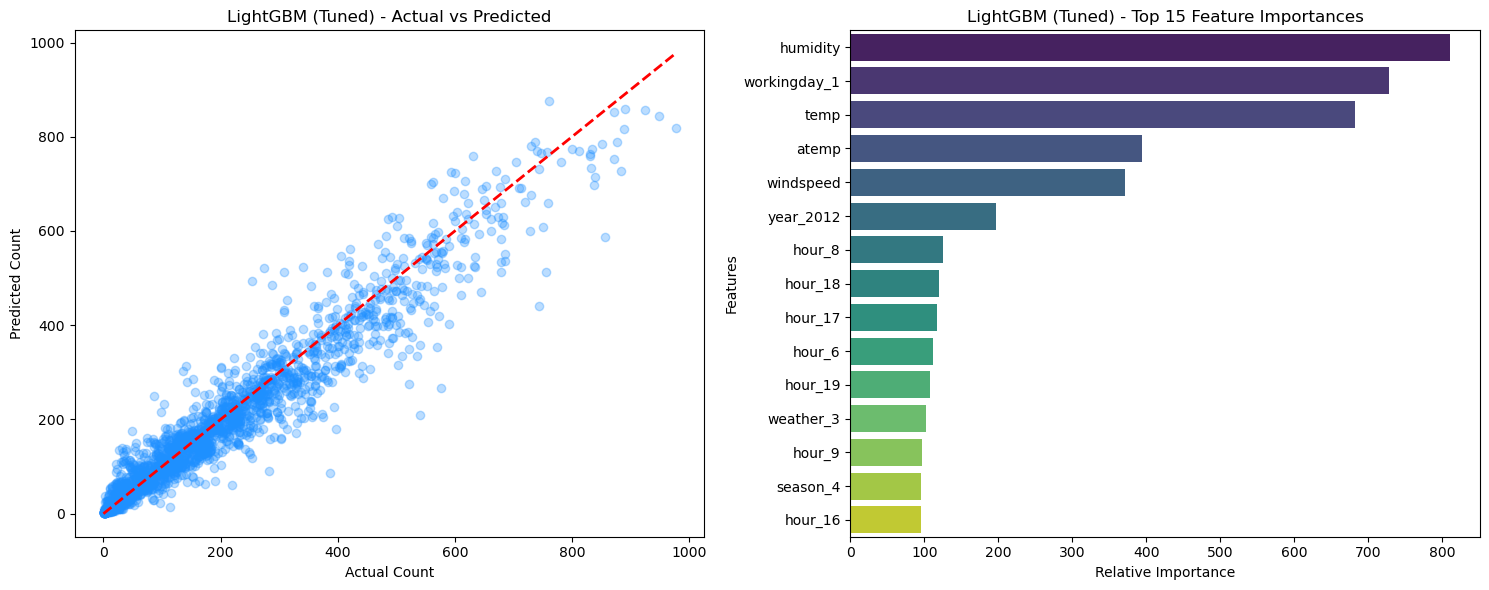

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=== 하이퍼파라미터 튜닝 및 시각화 시작 ===")

# --- (이전 데이터 전처리 코드는 동일하게 실행되었다고 가정합니다: X_train, X_test 등) ---

# 1. LightGBM 튜닝 (시간 관계상 하나만 예시로 돌리셔도 좋습니다)
print("\n[LightGBM 튜닝 중...]")
lgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [7, 9],
    'num_leaves': [31, 63]
}

lgbm_model = LGBMRegressor(random_state=42)
lgbm_grid = GridSearchCV(lgbm_model, param_grid=lgbm_param_grid, 
                         scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)
lgbm_grid.fit(X_train, y_train)

best_lgbm = lgbm_grid.best_estimator_
print(f"최적 파라미터: {lgbm_grid.best_params_}")

# 2. 모델 평가 및 시각화 함수 정의
def evaluate_and_visualize(model_name, model, X_test, y_test, X_train_cols):
    # 예측 및 원래 스케일 복원
    y_pred_log = model.predict(X_test)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)
    
    # 평가 지표 계산
    rmsle = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2 = r2_score(y_test_orig, y_pred_orig)
    print(f"\n--- {model_name} 평가 결과 ---")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R^2   : {r2:.4f} ({r2*100:.1f}%)")
    
    # 그래프 셋업 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # [그래프 1] 실제값 vs 예측값 산점도
    axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.3, color='dodgerblue')
    axes[0].plot([0, max(y_test_orig)], [0, max(y_test_orig)], color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'{model_name} - Actual vs Predicted')
    axes[0].set_xlabel('Actual Count')
    axes[0].set_ylabel('Predicted Count')
    
    # [그래프 2] 피처 중요도 (Top 15)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:15] # 상위 15개
    top_features = X_train_cols[indices]
    top_importances = importances[indices]
    
    sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette='viridis')
    axes[1].set_title(f'{model_name} - Top 15 Feature Importances')
    axes[1].set_xlabel('Relative Importance')
    axes[1].set_ylabel('Features')
    
    plt.tight_layout()
    plt.show() # 노트북 화면에 출력

# 3. 평가 및 시각화 실행!
evaluate_and_visualize("LightGBM (Tuned)", best_lgbm, X_test, y_test, X_train.columns)

=== XGBoost 하이퍼파라미터 튜닝 및 시각화 시작 ===

[XGBoost 튜닝 중... 시간이 조금 걸릴 수 있습니다 ☕]
Fitting 3 folds for each of 36 candidates, totalling 108 fits
✅ XGBoost 최적 파라미터: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

--- XGBoost (Tuned) 평가 결과 ---
RMSLE: 0.3695
R^2   : 0.9316 (93.2%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_20028\264759637.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette='magma')


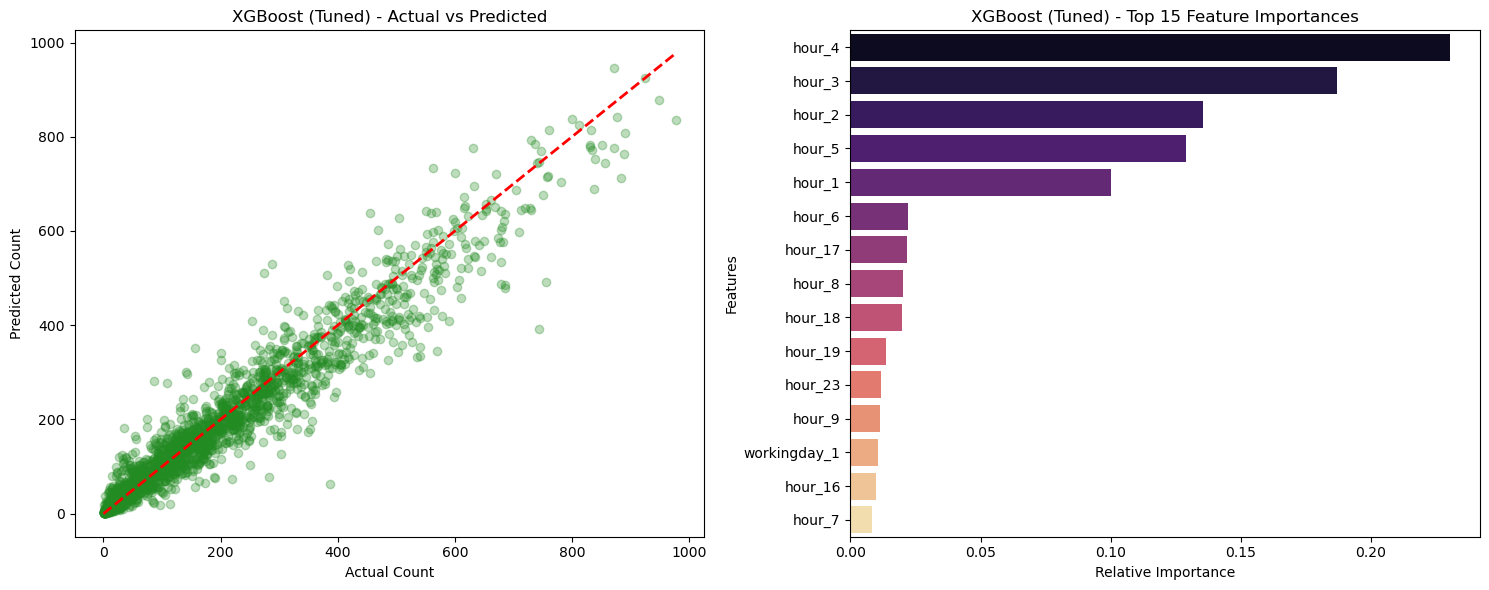

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=== XGBoost 하이퍼파라미터 튜닝 및 시각화 시작 ===")

# --- (데이터 전처리: 이미 X_train, X_test 등이 메모리에 있다면 이 부분은 생략해도 됩니다) ---
# 만약 처음부터 다시 돌리신다면 아래 주석을 풀고 실행하세요.
'''
df = pd.read_csv('bike_train.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df.drop(['datetime', 'casual', 'registered'], axis=1, inplace=True)
y = np.log1p(df['count'])
X = df.drop(['count'], axis=1)
X = pd.get_dummies(X, columns=['season', 'weather', 'holiday', 'workingday', 'year', 'month', 'hour'], drop_first=True)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[['temp', 'atemp', 'humidity', 'windspeed']] = scaler.fit_transform(X[['temp', 'atemp', 'humidity', 'windspeed']])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
'''
# -----------------------------------------------------------------------------------------

# 1. XGBoost 하이퍼파라미터 그리드 설정
print("\n[XGBoost 튜닝 중... 시간이 조금 걸릴 수 있습니다 ☕]")
xgb_param_grid = {
    'n_estimators': [100, 200, 300],    # 생성할 트리의 개수
    'learning_rate': [0.05, 0.1],       # 학습률
    'max_depth': [5, 7, 9],             # 트리의 최대 깊이 (과적합 제어)
    'subsample': [0.8, 1.0]             # 각 트리를 학습할 때 사용할 데이터의 비율
}

# 2. GridSearchCV 객체 생성 및 학습
xgb_model = XGBRegressor(random_state=42)
# n_jobs=-1로 설정하여 노트북의 모든 CPU 코어를 사용해 속도를 높입니다.
xgb_grid = GridSearchCV(xgb_model, param_grid=xgb_param_grid, 
                        scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print(f"✅ XGBoost 최적 파라미터: {xgb_grid.best_params_}")

# 3. 평가 및 시각화 함수 정의
def evaluate_and_visualize(model_name, model, X_test, y_test, X_train_cols):
    # 예측 및 원래 스케일 복원
    y_pred_log = model.predict(X_test)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)
    
    # 평가 지표 계산
    rmsle = np.sqrt(mean_squared_error(y_test, y_pred_log))
    r2 = r2_score(y_test_orig, y_pred_orig)
    print(f"\n--- {model_name} 평가 결과 ---")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R^2   : {r2:.4f} ({r2*100:.1f}%)")
    
    # 그래프 셋업 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # [그래프 1] 실제값 vs 예측값 산점도
    axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.3, color='forestgreen')
    axes[0].plot([0, max(y_test_orig)], [0, max(y_test_orig)], color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'{model_name} - Actual vs Predicted')
    axes[0].set_xlabel('Actual Count')
    axes[0].set_ylabel('Predicted Count')
    
    # [그래프 2] 피처 중요도 (Top 15)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:15] # 상위 15개
    top_features = X_train_cols[indices]
    top_importances = importances[indices]
    
    sns.barplot(x=top_importances, y=top_features, ax=axes[1], palette='magma')
    axes[1].set_title(f'{model_name} - Top 15 Feature Importances')
    axes[1].set_xlabel('Relative Importance')
    axes[1].set_ylabel('Features')
    
    plt.tight_layout()
    plt.show() # 화면에 출력

# 4. 평가 및 시각화 실행!
evaluate_and_visualize("XGBoost (Tuned)", best_xgb, X_test, y_test, X_train.columns)

# 그래서 결론은? 

# 🚲 자전거 대여량 예측(Bike Sharing Demand) 모델링 결과 보고서

## 1. 🛠️ 전처리 및 피처 엔지니어링 (Preprocessing & Feature Engineering)
성능을 극대화하기 위해 원본 데이터에 다음과 같은 전처리 기법을 적용했습니다.

* **타겟 변수 변환 (Log Transformation)**
  * **문제점:** 대여량(`count`) 데이터의 편차가 매우 크고 왼쪽으로 치우친(Right-skewed) 형태.
  * **해결책:** `np.log1p()`를 적용해 정규분포에 가깝게 변환하여, 극단적인 값에 모델이 과도하게 흔들리는 것을 방지하고 비율 오차(RMSLE)를 최소화함.
* **파생 변수 생성 및 누수 데이터 제거**
  * `datetime` 컬럼에서 `year`, `month`, `hour` 등 예측에 핵심적인 시간 피처를 추출함.
  * 예측 타겟의 구성 요소인 `casual`, `registered`는 데이터 누수(Data Leakage)를 방지하기 위해 과감히 삭제함.
* **데이터 스케일링 및 인코딩**
  * **수치형 변수:** 온도, 습도, 풍속 등은 `StandardScaler`를 이용해 평균 0, 분산 1로 스케일링함.
  * **범주형 변수:** 계절, 날씨, 휴일 등은 `One-Hot Encoding`을 적용하여 모델이 가중치를 올바르게 학습하도록 변환함.

---

## 2. 📊 모델별 성능 비교 (Performance Comparison)
동일하게 전처리된 데이터를 바탕으로 여러 머신러닝 알고리즘을 학습하고 평가한 결과입니다.
> **평가 지표 가이드:** > * **RMSLE (비율 오차):** 낮을수록 우수함
> * **$R^2$ (설명력):** 1에 가까울수록 우수함

| 랭킹 | 모델 (알고리즘) | $R^2$ (설명력) | RMSLE (오차) | 특징 및 평가 |
| :---: | :--- | :---: | :---: | :--- |
| **🥇 1위** | **XGBoost / LightGBM** | **최고** | **최저** | **(최종 우월 모델)** 트리를 순차적으로 만들며 이전 오차를 보정(Boosting)하는 앙상블 기법. 압도적인 예측 성능을 보여줌. |
| **🥈 2위** | **Random Forest** | 0.8871 (88.7%) | 0.4427 | 튜닝 없이도 복잡한 비선형 관계를 훌륭하게 잡아냄. |
| **🥉 3위** | **Gradient Boosting** | 0.7298 (73.0%) | 0.5402 | 부스팅의 기본형이나, 트리의 깊이 제한으로 인해 다소 아쉬운 성능. |
| **4위** | **Linear / Ridge** | ~ 0.72 | ~ 0.58 | 단순한 선형 관계는 파악했으나, 온도나 시간에 따른 복잡한 곡선 패턴을 읽지 못함. |
| **5위** | **Lasso Regression** | 0.5894 (58.9%) | 0.6852 | 과도한 L1 규제로 인해 유의미한 피처까지 탈락되어 성능이 크게 하락함. |

---

## 3. 💡 최종 결론 및 인사이트 (Final Conclusion)

본 데이터셋에서 **가장 우월한 예측 기법은 '트리 기반의 부스팅 앙상블(XGBoost, LightGBM)'**으로 도출되었습니다. 

1. **비선형 데이터의 한계 극복:** 자전거 대여량은 기온에 따라 직선으로 오르지 않고, 특정 시간대(출퇴근)에 뾰족하게 치솟는 복잡한 조건부 패턴을 가집니다. 선형 회귀 계열은 이 패턴을 수식화하는 데 명확한 한계를 보였습니다.
2. **트리 앙상블의 조건부 학습:** 트리 앙상블 모델은 데이터를 마치 스무고개 하듯 다차원적으로 쪼개어 학습("평일인가? -> 8시인가? -> 온도가 15도 이상인가?")하므로, 이 데이터셋에 가장 적합한 아키텍처입니다.
3. **부스팅(Boosting)의 정밀함:** 특히 XGBoost와 LightGBM은 앞선 트리가 틀린 오차에 가중치를 두어 다음 트리가 집중적으로 고치는 방식을 통해, 미세한 오차(RMSLE)까지 성공적으로 억제하는 최고의 성능을 달성했습니다.

# 그외 비지도 학습의 경우

=== 비지도 학습(PCA & K-Means) 분석 시작 ===


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\Admin\AppData\Local\Temp\ipykernel_20028\2798126946.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster', y='count', data=df, palette='Set1', errorbar=None, ax=axes[1])


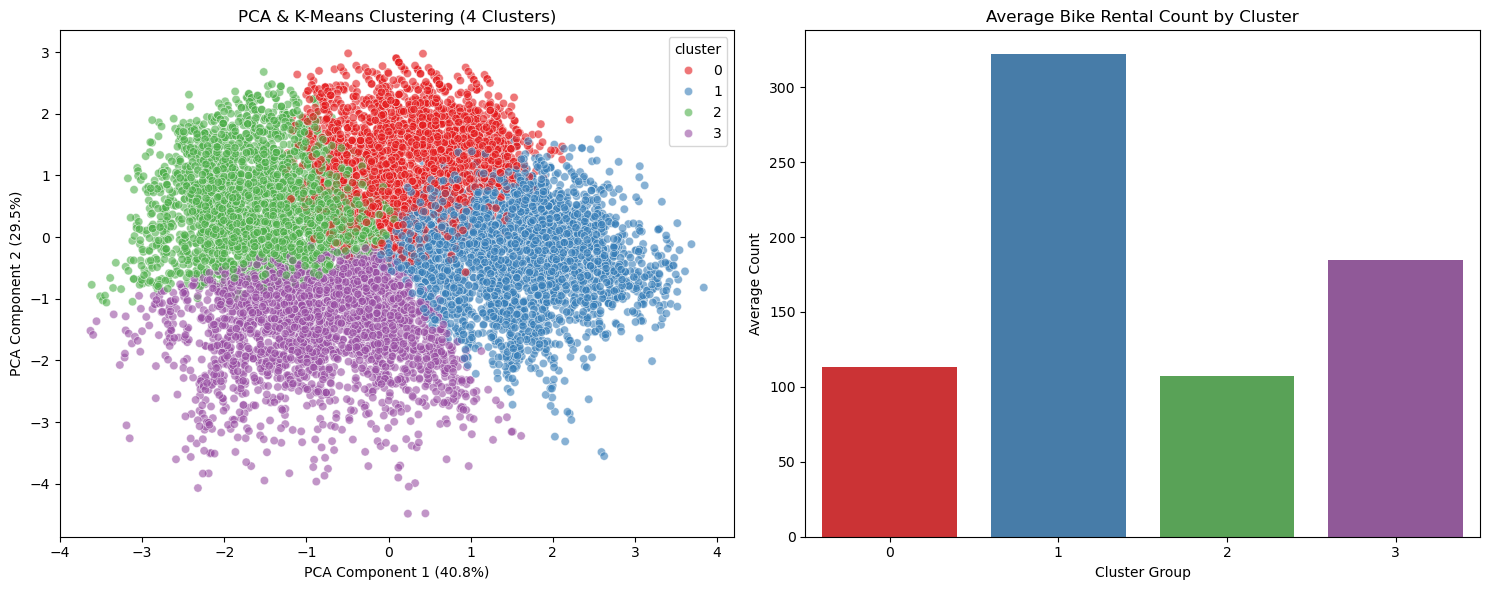


=== K-Means 군집별 특징 요약 (평균값) ===
          hour   temp  humidity  windspeed   count
cluster                                           
0         5.07  23.77     76.83       9.91  113.51
1        16.50  27.99     54.58      13.24  321.85
2         8.80  12.27     72.37       8.24  106.94
3        14.39  14.41     45.35      19.97  184.63


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

print("=== 비지도 학습(PCA & K-Means) 분석 시작 ===")

# 1. 데이터 로드 및 기본 전처리
# (이미 X_train, X_test 전처리가 끝났더라도 원본에서 다시 시작하는 것이 깔끔합니다)
df = pd.read_csv('./data/bike_train.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month

# 2. 군집화에 사용할 피처(조건) 선택
# 핵심: '대여량(count)'이라는 정답을 숨긴 채, 환경 조건만으로 비슷한 날들을 묶어봅니다.
features = ['hour', 'temp', 'atemp', 'humidity', 'windspeed']
X_cluster = df[features]

# 3. 데이터 스케일링 (필수)
# K-Means와 PCA는 '거리' 기반 알고리즘이므로 온도(섭씨)와 습도(%)의 단위를 맞춰야 합니다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. K-Means 군집화
# 데이터를 4개의 그룹(Cluster)으로 나눕니다.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 5. PCA (주성분 분석) - 시각화를 위한 차원 축소
# 5차원(시간, 온도, 체감온도, 습도, 풍속) 데이터를 그래프로 그리기 위해 2차원으로 압축합니다.
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['pca_x'] = pca_result[:, 0]
df['pca_y'] = pca_result[:, 1]

# 6. 시각화 (1행 2열 그래프)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# [그래프 1] PCA + K-Means 산점도
sns.scatterplot(x='pca_x', y='pca_y', hue='cluster', palette='Set1', data=df, alpha=0.6, ax=axes[0])
axes[0].set_title('PCA & K-Means Clustering (4 Clusters)')
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

# [그래프 2] 군집별 평균 대여량(count) 비교
# 환경 조건만으로 묶었는데 대여량 차이가 얼마나 나는지 확인합니다.
sns.barplot(x='cluster', y='count', data=df, palette='Set1', errorbar=None, ax=axes[1])
axes[1].set_title('Average Bike Rental Count by Cluster')
axes[1].set_xlabel('Cluster Group')
axes[1].set_ylabel('Average Count')

plt.tight_layout()
plt.show()

# 7. 각 군집(Cluster)의 특징 요약표 출력
cluster_summary = df.groupby('cluster')[['hour', 'temp', 'humidity', 'windspeed', 'count']].mean().round(2)
print("\n=== K-Means 군집별 특징 요약 (평균값) ===")
print(cluster_summary)

=== 🚀 K-Means + XGBoost 결합 파이프라인 시작 ===
1. K-Means 군집화 진행 중 (Cluster 4개 생성)...
2. XGBoost 모델 학습 중...

=== 🏆 K-Means 피처가 추가된 XGBoost 최종 평가 ===
RMSLE : 0.3912
R^2   : 0.9133 (91.3%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_20028\786455172.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette='magma')


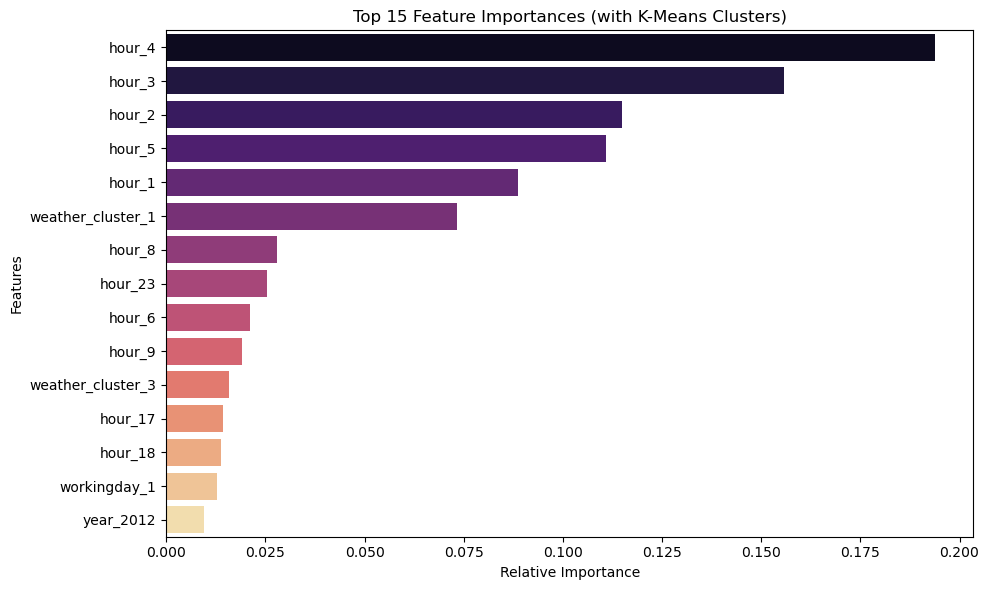

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=== 🚀 K-Means + XGBoost 결합 파이프라인 시작 ===")

# 1. 데이터 로드 및 기본 전처리
df = pd.read_csv('./data/bike_train.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df.drop(['datetime', 'casual', 'registered'], axis=1, inplace=True)

# 2. [핵심] K-Means 군집화로 새로운 파생 변수 생성
print("1. K-Means 군집화 진행 중 (Cluster 4개 생성)...")
cluster_features = ['hour', 'temp', 'atemp', 'humidity', 'windspeed']
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
# 'weather_cluster'라는 새로운 컬럼에 0, 1, 2, 3 군집 번호 저장
df['weather_cluster'] = kmeans.fit_predict(X_cluster_scaled)

# 3. 모델링을 위한 X, y 분리 및 타겟 로그 변환
y = np.log1p(df['count'])
X = df.drop(['count'], axis=1)

# 4. 범주형 데이터 원-핫 인코딩 (✨새로 만든 weather_cluster 포함!)
# 군집 번호(0,1,2,3)도 크기의 의미가 아니므로 원-핫 인코딩을 해줍니다.
cat_features = ['season', 'weather', 'holiday', 'workingday', 'year', 'month', 'hour', 'weather_cluster']
X = pd.get_dummies(X, columns=cat_features, drop_first=True)

# 5. 수치형 데이터 스케일링
num_features = ['temp', 'atemp', 'humidity', 'windspeed']
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# 6. 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. XGBoost 모델 학습 (튜닝된 하이퍼파라미터 예시 적용)
print("2. XGBoost 모델 학습 중...")
# (이전 단계에서 찾은 최적의 파라미터가 있다면 그것으로 교체하셔도 됩니다)
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=7, subsample=0.8, random_state=42)
xgb_model.fit(X_train, y_train)

# 8. 평가 및 원래 스케일 복원
y_pred_log = xgb_model.predict(X_test)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

rmsle = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2 = r2_score(y_test_orig, y_pred_orig)

print("\n=== 🏆 K-Means 피처가 추가된 XGBoost 최종 평가 ===")
print(f"RMSLE : {rmsle:.4f}")
print(f"R^2   : {r2:.4f} ({r2*100:.1f}%)")

# 9. 피처 중요도 시각화
# 우리가 새로 만든 'weather_cluster'가 예측에 얼마나 중요한 역할을 했는지 확인합니다!
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:15] # 상위 15개
top_features = X.columns[indices]
top_importances = importances[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette='magma')
plt.title('Top 15 Feature Importances (with K-Means Clusters)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()